# Prelimenary Blame Detection (PBD)

#### This pipeline serves to do prelimenary localization of blame on translated model data for computationally asssisted labeling of blame. To achieve this goal, the following conceptual steps will be implemented:

- Prepare hypothesis for NLI DEBATE model
- Setup for model
- Read translated sentences
- Pass translated sentences to each hypothesis
- For each hypothesis, evaluate blame based on heuristics of certainty of blame
- 

# OBS change model to large when cuda is available. Currently runs on base

In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path("../../src").resolve()))

from PBD import DebateEntailment
from pathlib import Path
import os

In [2]:

input_path = Path(os.path.join("..",
                           "..",
                           "raw_data",
                           "test_json_modelling_data_translated.jsonl"))

output_path = Path(os.path.join("..",
                           "..",
                           "raw_data",
                           "test_json_modelling_data_translated_PBD.jsonl"))

In [3]:
DE = DebateEntailment(inpath=input_path,
                      outpath=output_path,
                      batch_size=2)

DE.run_hypothesis_entailment()

Reading input .jsonl file...

Initializing outpath...

Device: cpu
remember to change to large. Currently base


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

now for this hypothesis:
Based on this text, the author's attitude towards others is best described as {}
this is self.hypothesis_number:
1


Applying blame detection with hypothesis nr: 1: 100%|██████████| 25/25 [00:36<00:00,  1.45s/it]


now for this hypothesis:
Overall, the author's stance toward others in this passage is {}
this is self.hypothesis_number:
2
Reading input .jsonl file...



...

Applying blame detection with hypothesis nr: 3: 100%|██████████| 25/25 [00:22<00:00,  1.10it/s]


now for this hypothesis:
According to this passage, the author's reaction to others' conduct can be described as {}
this is self.hypothesis_number:
4
Reading input .jsonl file...



Applying blame detection with hypothesis nr: 4: 100%|██████████| 25/25 [00:24<00:00,  1.04it/s]


now for this hypothesis:
From the way others are described, the author's expression towards them is best described as {}
this is self.hypothesis_number:
5
Reading input .jsonl file...



Applying blame detection with hypothesis nr: 5: 100%|██████████| 25/25 [00:22<00:00,  1.11it/s]


# Terminal

Can also be run from terminal with arguments. Shoudl automatically detect CUDA

Required:
--input_path_jsonl <path/to/translated/data> 
--output_path_jsonl <path/to/translated/with/PBD>

Optional
--batch_size int (default: 2)





# Prelimenary dataset creating


This part serves to create five datasets of differentiated level og agreement between templates. These datasets are to be used to find the most representative account of blame by level of conservatism operationalized by the level og agreement between entailment of blame by hypothesis template.

A validation set will also be made of provided size. The validation set will be balanced. SO if not enough true labels are found, size will be twice that of true labels available. Text which is part of validation set are excluded from the five datasets of different levels of agreement.

A cleanup function has been incoorporated so that no-longer-used entries are deleted to save space

Additionally, this pipeline also provids minimalistic visual and statistical representation of the template-wise differences in amount of entailment of blame found pr template

In [10]:
import os
from pathlib import Path

import importlib
import template_manipulation

importlib.reload(template_manipulation)

from template_manipulation import TemplateManipulation

In [11]:
#setup paths
inpath = Path(os.path.join("..",
                           "..",
                           "raw_data",
                           "test_json_modelling_data_translated_PBD.jsonl"))

outpath = Path(os.path.join("..",
                           "..",
                           "raw_data",
                           "test_json_modelling_data_translated_PBD_agreement.jsonl"))


# make list of keys to delete for datasets of different agreement and validation file

omit_keys = ["translated_text", "n_hyp_entail"]

n_hyp = 5
for i in range(1,n_hyp +1):
    key_name = f"Hyp_{i}_blame"

    omit_keys.append(key_name)

print(omit_keys)

['translated_text', 'n_hyp_entail', 'Hyp_1_blame', 'Hyp_2_blame', 'Hyp_3_blame', 'Hyp_4_blame', 'Hyp_5_blame']


number of hypothesis templates detected: 5...



Adding key 'n_hyp entail' to: ..\..\raw_data\test_json_modelling_data_translated_PBD_agreement.jsonl...: 50it [00:00, 16522.11it/s]


Making output directory for datasets of different levels of agreement:
..\..\raw_data\test_diff_hypothesis_agreemen

Validation set created with 6 records: 3 true labels, 3 false labels.
Validation set written to ..\..\raw_data\training\validation\label_studio\initial_validation_set.jsonl
Setting up writers for labeling by level of agreement...



Reading input and writing output files for threshold of agreement...: 50it [00:00, 10287.22it/s]
Reading lines of output file for statistics...: 50it [00:00, ?it/s]


Total samples: 50

=== Per-threshold agreement percentages ===
Agreement ≥ 1 hypotheses: 6.00%
Agreement ≥ 2 hypotheses: 2.00%
Agreement ≥ 3 hypotheses: 2.00%
Agreement ≥ 4 hypotheses: 2.00%
Agreement ≥ 5 hypotheses: 2.00%

=== Per-hypothesis percentages ===
Hyp_1_blame: 2.00%
Hyp_2_blame: 2.00%
Hyp_3_blame: 4.00%
Hyp_4_blame: 4.00%
Hyp_5_blame: 2.00%


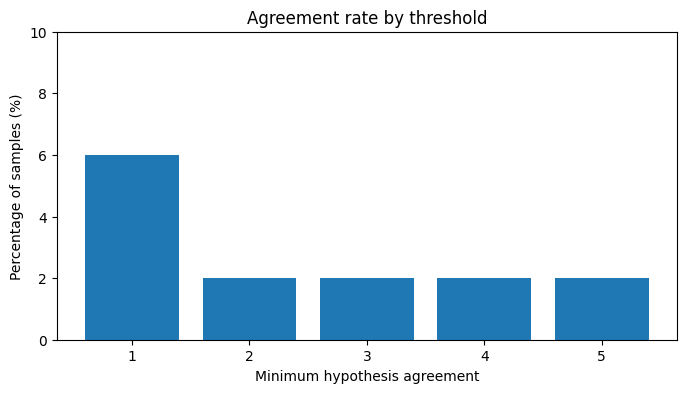

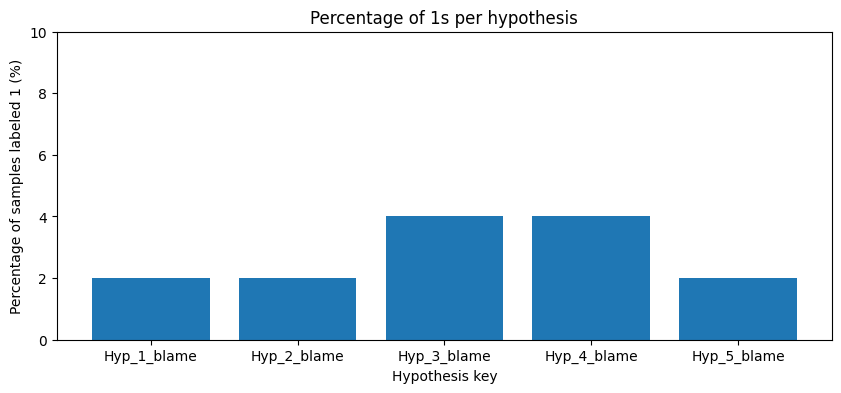

In [12]:
TM = TemplateManipulation(input_path = inpath,
                            output_path = outpath,
                            validation_size = 300, 
                            clean_keys = omit_keys)

TM.create_datasets()
TM.run_statistics(ylim=10)

The above pipeline can be run from terminal by using the following commands

python template_manipulation.py --input_path <path/to/translated_PBD.jsonl> --output_path <path/to/save_agreement_of_hypothesis.jsonl>

optional arguments:

--ylim int (y limit for plot showing statistics, default 10)
--validation_size int (size of validation size to attempt extraction, default 300)
--clean_keys (repeated arguments for keys to exclude, i.e: --clean_keys Hyp_1_blame Hyp_2_blame Hyp_3_blame)